In [1]:
from torch.utils.data import DataLoader
from dataset import RavensEpisodeDataset, collate_fn
data_dir = 'place-red-in-green-train-noise0.002'
dataset = RavensEpisodeDataset(data_dir, obs_keys=['ee_pose', 'obj_pose', 'goal_pose'], normalize_actions=True, 
                              normalization_stats_path=data_dir, debug=True, debug_episode_path="/gscratch/socialrl/sriyash/ravens/place-red-in-green-train-noise0.002/color/000000-118.pkl")
loader = DataLoader(dataset, batch_size=10000, shuffle=True, collate_fn=collate_fn, num_workers=4, prefetch_factor=2)

import tqdm
for batch in tqdm.tqdm(loader):
    obs = batch['obs']           # dict of (B, T, 3, H, W)
    ee_poses = obs['ee_pose']   # (B, T, 7)
    obj_poses = obs['obj_pose']   # (B, T, 7)
    goal_poses = obs['goal_pose']   # (B, T, 7)
    # images = batch['images']       # (1, T, 3, H, W)
    actions = batch['actions']
    attention_mask = batch['attention_mask']

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.01it/s]


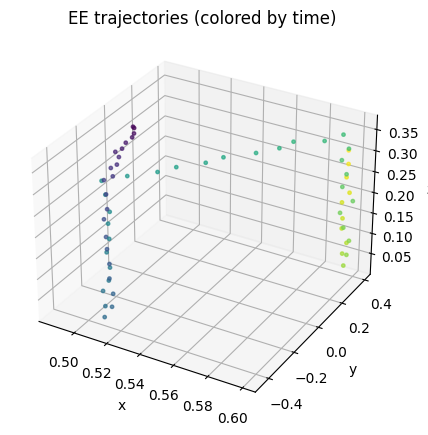

In [2]:
import numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def _np(x):
    try:
        import torch
        return x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)
    except Exception:
        return np.asarray(x)

ee = _np(ee_poses)          # (B, T, 7)
mask = _np(attention_mask).astype(bool)  # (B, T)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")

B, T, _ = ee.shape
for b in range(B):
    L = int(mask[b].sum())
    # L = 1
    if L == 0: 
        continue
    xyz = ee[b, :L, :3]
    t = np.linspace(0, 1, L)
    ax.scatter(xyz[:,0], xyz[:,1], xyz[:,2], c=t, cmap="viridis", s=6, alpha=0.7)

ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("EE trajectories (colored by time)")
plt.show()


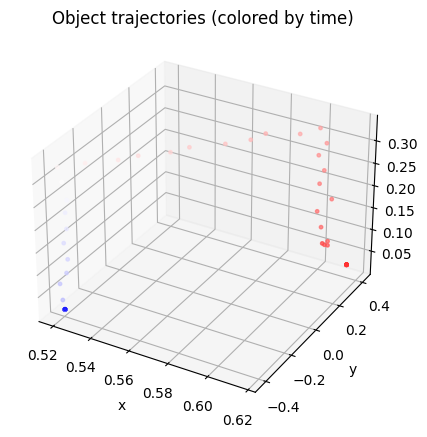

In [3]:
import numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def _np(x):
    try:
        import torch
        return x.detach().cpu().numpy() if "torch" in str(type(x)) else np.asarray(x)
    except Exception:
        return np.asarray(x)

obj = _np(obj_poses)        # (B, T, 7)
mask = _np(attention_mask).astype(bool)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")

B, T, _ = obj.shape
for b in range(B):
    L = int(mask[b].sum())
    if L == 0:
        continue
    xyz = obj[b, :L, :3]
    t = np.linspace(0, 1, L)
    ax.scatter(xyz[:,0], xyz[:,1], xyz[:,2], c=t, cmap="bwr", s=6, alpha=0.7)

ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("Object trajectories (colored by time)")
plt.show()


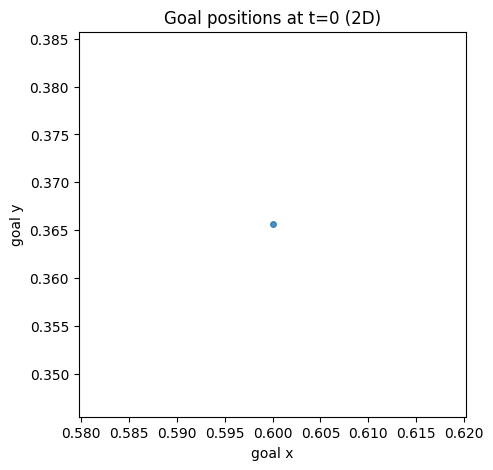

In [4]:
import numpy as np, matplotlib.pyplot as plt

def _np(x):
    try:
        import torch
        return x.detach().cpu().numpy() if "torch" in str(type(x)) else np.asarray(x)
    except Exception:
        return np.asarray(x)

goals = _np(goal_poses)     # (B, T, 7)
xy0 = goals[:, 0, :2]       # (B, 2)

plt.figure(figsize=(5, 5))
plt.scatter(xy0[:,0], xy0[:,1], s=16, alpha=0.8)
plt.xlabel("goal x"); plt.ylabel("goal y")
plt.title("Goal positions at t=0 (2D)")
plt.axis("equal")
plt.show()


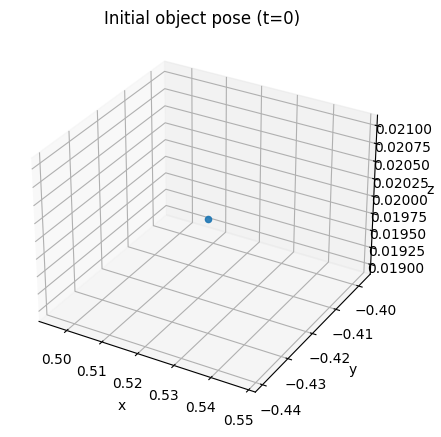

In [5]:
import numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def _np(x):
    try:
        import torch
        return x.detach().cpu().numpy() if "torch" in str(type(x)) else np.asarray(x)
    except Exception:
        return np.asarray(x)

obj = _np(obj_poses)        # (B, T, 7)
xyz0 = obj[:, 0, :3]        # (B, 3)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(xyz0[:,0], xyz0[:,1], xyz0[:,2], s=20, alpha=0.9)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("Initial object pose (t=0)")
plt.show()


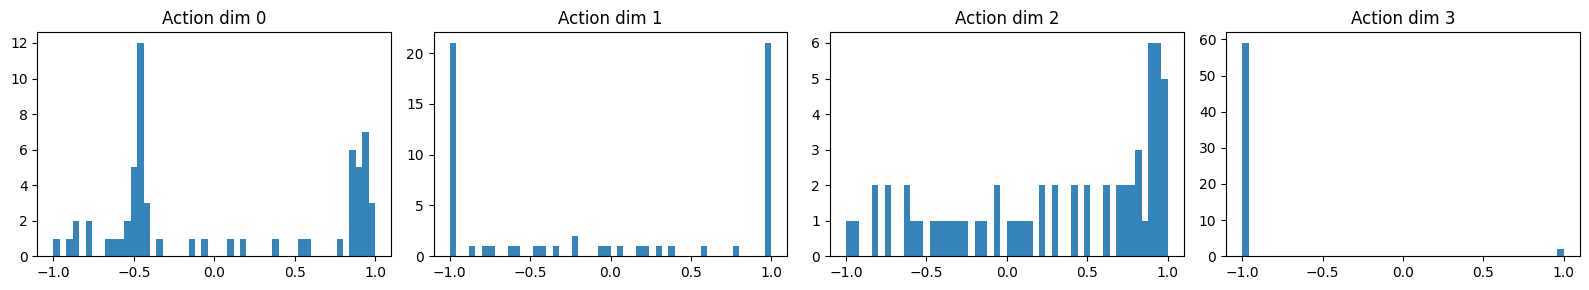

In [6]:
import numpy as np, matplotlib.pyplot as plt

def _np(x):
    try:
        import torch
        return x.detach().cpu().numpy() if "torch" in str(type(x)) else np.asarray(x)
    except Exception:
        return np.asarray(x)

acts = _np(actions)                 # (B, T, D)
mask = _np(attention_mask).astype(bool)  # (B, T)

B, T, D = acts.shape
valid = np.concatenate([acts[b, :mask[b].sum(), :] for b in range(B) if mask[b].any()], axis=0)  # (N, D)

fig, axs = plt.subplots(1, D, figsize=(4*D, 3), squeeze=False)
for d in range(D):
    axs[0, d].hist(valid[:, d], bins=50, alpha=0.9)
    axs[0, d].set_title(f"Action dim {d}")
plt.tight_layout()
plt.show()


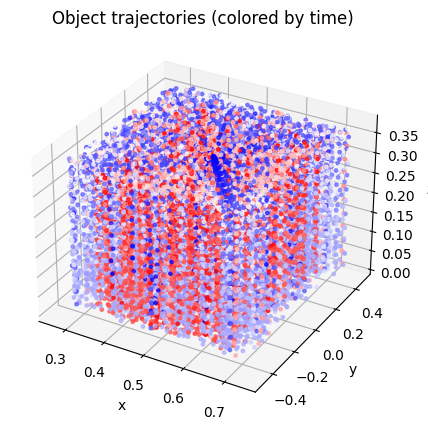

In [12]:
import numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def _np(x):
    try:
        import torch
        return x.detach().cpu().numpy() if "torch" in str(type(x)) else np.asarray(x)
    except Exception:
        return np.asarray(x)

obj = _np(actions)        # (B, T, 7)
mask = _np(attention_mask).astype(bool)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")

B, T, _ = obj.shape
for b in range(B):
    L = int(mask[b].sum())
    if L == 0:
        continue
    xyz = obj[b, :L, :3]
    t = np.linspace(0, 1, L)
    ax.scatter(xyz[:,0], xyz[:,1], xyz[:,2], c=t, cmap="bwr", s=6, alpha=0.7)

ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("Object trajectories (colored by time)")
plt.show()


In [4]:
for k,v in obs.items():
    print(k, v.shape)

ee_pose torch.Size([1, 61, 7])
obj_pose torch.Size([1, 61, 7])
goal_pose torch.Size([1, 61, 7])


In [9]:
import os
import hydra
import torch
import wandb
import pybullet as p
from omegaconf import OmegaConf
from ravens.environments.environment import Environment, ContinuousEnvironment
from ravens import tasks
# from dataset import RavensEpisodeDataset  # for transforms
from model import ActionPredictionModel
from transformers import GPT2Config
from torchvision.utils import make_grid
import numpy as np
import torchvision.transforms as transforms
from ravens.env_worker import get_obj_id_and_goal

assets_root = "./ravens/environments/assets" #model_cfg.data.value.assets_root
task_name = "place-red-in-green" #model_cfg.data.value.task
mode = 'train'
continuous = True
steps_per_seg = 3
# env = Environment(assets_root, disp=False, shared_memory=False)
env_cls = ContinuousEnvironment if continuous else Environment
env = env_cls(
  assets_root,
  disp=False,
  shared_memory=True,
  hz=480)
task = tasks.names[task_name](continuous=continuous)
task.mode = mode
env.set_task(task)

agent = task.oracle(env, steps_per_seg=steps_per_seg)
max_steps = task.max_steps
if continuous:
    max_steps *= (steps_per_seg * agent.num_poses)
max_steps = int(max_steps)


In [11]:
from eval import EvalEnvWrapper
env = EvalEnvWrapper(env,['ee_pose', 'goal_pose', 'obj_pose'], -1)

In [18]:
for _ in range(5):
    debug_seed = 118
    np.random.seed(debug_seed)
    reset_obs = env.reset()
    for k,v in obs.items():
        reset_v = reset_obs[k]
        v = v[0,0]
        err = reset_v - v.numpy()
        print(k, np.linalg.norm(err))
    print("----")

ee_pose 1.1780328366889407e-08
obj_pose 2.6659755661566706e-08
goal_pose 3.554432663819208e-08
----
ee_pose 1.1780328366889407e-08
obj_pose 2.6659755661566706e-08
goal_pose 3.554432663819208e-08
----
ee_pose 1.1780328366889407e-08
obj_pose 2.6659755661566706e-08
goal_pose 3.554432663819208e-08
----
ee_pose 1.1780328366889407e-08
obj_pose 2.6659755661566706e-08
goal_pose 3.554432663819208e-08
----
ee_pose 1.1780328366889407e-08
obj_pose 2.6659755661566706e-08
goal_pose 3.554432663819208e-08
----


In [19]:
for _ in range(5):
    debug_seed = 119
    np.random.seed(debug_seed)
    reset_obs = env.reset()
    for k,v in obs.items():
        reset_v = reset_obs[k]
        v = v[0,0]
        err = reset_v - v.numpy()
        print(k, np.linalg.norm(err))
    print("----")

ee_pose 1.1780328366889407e-08
obj_pose 0.13054122482254318
goal_pose 0.26952861770345393
----
ee_pose 1.1780328366889407e-08
obj_pose 0.13054122482254318
goal_pose 0.26952861770345393
----
ee_pose 1.1780328366889407e-08
obj_pose 0.13054122482254318
goal_pose 0.26952861770345393
----
ee_pose 1.1780328366889407e-08
obj_pose 0.13054122482254318
goal_pose 0.26952861770345393
----
ee_pose 1.1780328366889407e-08
obj_pose 0.13054122482254318
goal_pose 0.26952861770345393
----
